# SETAR, SETAR-Tree and SETAR-Forest

This notebook demonstrates the **SETAR** family of forecasters in the `aeon` toolkit. SETAR — **S**elf-**E**xciting **T**hreshold **A**uto**R**egression — is a *nonlinear* extension of autoregression. Where a linear AR model (the AR part of [ARIMA](../stats/arima.ipynb)) uses one fixed set of coefficients, a SETAR model switches between **different AR models depending on the recent state of the series itself** — hence "self-exciting". This lets it capture regime-dependent behaviour: series that behave differently when they are high vs low, rising vs falling, calm vs volatile.

Three related forecasters live in `aeon.forecasting.machine_learning`:

- **`SETAR`** — the classical two-regime threshold model.
- **`SETARTree`** — a regression tree that recursively splits on thresholds, generalising SETAR to many regimes; a **global** model trained across collections of series.
- **`SETARForest`** — a bagged ensemble of SETAR-Trees.

> H. Tong (1990). *Non-linear Time Series: A Dynamical System Approach.* Oxford University Press. (classical SETAR)
>
> R. Godahewa, C. Bergmeir, G. Webb, P. Montero-Manso & R. Hyndman (2023). SETAR-Tree: a novel and accurate tree algorithm for global time series forecasting. *Machine Learning*, 112, 2555-2591.


Critically, SETAR-Tree and SETAR-Forest are **global** forecasters: a single tree is trained across a whole *collection* of series at once, rather than one model per series. Section 6 explains what that means and how to use it.


## 2. Parameters and their effects

**`SETAR`**
- **`lag`** (default `10`): the maximum AR order to attempt. SETAR tries decreasing lag orders until it finds a valid two-regime split, falling back to a plain linear AR if none works.

**`SETARTree`** (key parameters)
- **`lag`** (default `10`): number of past lags used as features.
- **`max_depth`** (default `10`): maximum tree depth (number of nested regimes).
- **`stopping_criteria`** (default `"both"`): `"lin_test"` (F-test for linearity), `"error_imp"` (minimum error reduction), or `"both"`.
- **`significance`** (default `0.05`) and **`error_threshold`** (default `0.03`): how strict the split tests are. Lower significance / higher error_threshold &rarr; fewer splits, simpler tree.
- **`n_thresholds`** (default `15`): candidate cut points scanned per lag.

**`SETARForest`** (additional)
- **`n_estimators`** (default `10`): number of trees.
- **`bagging_fraction`** (default `0.8`): row sample fraction per tree.
- **`feature_fraction`** (default `1.0`): lag-feature sample fraction per tree.
- **`random_state`** (default `1`): controls the sampling.


## 3. Forecasting with SETAR

### Imports


In [1]:
import matplotlib.pyplot as plt
import numpy as np

from aeon.forecasting import RegressionForecaster
from aeon.forecasting.machine_learning import SETAR, SETARForest, SETARTree

### A series with two regimes

To show SETAR doing something a linear model cannot, we build a series with genuinely **regime-dependent** dynamics: when the previous value is below 0 it gets an upward push, and when it is above 0 a downward pull. This produces asymmetric, self-correcting cycles.


One-step-ahead forecast: 1.359


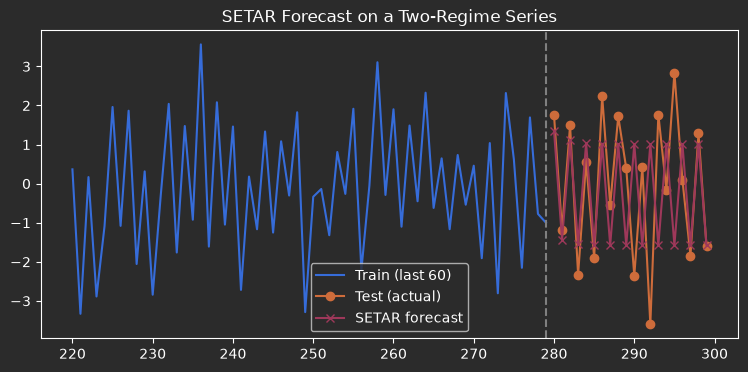

Test MSE over 20 steps: 3.905


In [2]:
rng = np.random.default_rng(7)
n = 300
y = np.zeros(n)
threshold_true = 0.0
for t in range(2, n):
    if y[t - 1] <= threshold_true:  # low regime: push up
        y[t] = 2.0 + 0.5 * y[t - 1] + rng.normal(scale=1.0)
    else:  # high regime: pull down
        y[t] = -2.0 + 0.5 * y[t - 1] + rng.normal(scale=1.0)

y_train, y_test = y[:-20], y[-20:]

forecaster = SETAR(lag=2)
forecaster.fit(y_train)
print(f"One-step-ahead forecast: {forecaster.forecast(y_train):.3f}")

y_preds = forecaster.iterative_forecast(y_train, prediction_horizon=20)

test_time = np.arange(len(y_train), len(y))
plt.figure(figsize=(9, 4))
plt.plot(np.arange(len(y_train))[-60:], y_train[-60:], label="Train (last 60)")
plt.plot(test_time, y_test, marker="o", label="Test (actual)")
plt.plot(test_time, y_preds, marker="x", label="SETAR forecast")
plt.axvline(x=len(y_train) - 1, linestyle="--", color="grey")
plt.legend()
plt.title("SETAR Forecast on a Two-Regime Series")
plt.show()

print(f"Test MSE over 20 steps: {np.mean((y_test - y_preds) ** 2):.3f}")

## 4. Worked example: the recovered regimes

SETAR exposes everything it learned. Because we generated the data, we can check that it recovered the true threshold (0.0) and the two regimes' intercepts (+2.0 and -2.0):


In [3]:
print(f"model type     : {forecaster.model}")
print(f"AR order used  : {forecaster.current_lag}")
print(f"threshold      : {forecaster.threshold:.3f}   (true 0.0)")
print(
    f"low  regime    : intercept={forecaster.intercept_low:+.3f}, "
    f"coefs={np.round(forecaster.coefs_low, 3)}   (true intercept +2.0)"
)
print(
    f"high regime    : intercept={forecaster.intercept_high:+.3f}, "
    f"coefs={np.round(forecaster.coefs_high, 3)}   (true intercept -2.0)"
)

model type     : setar
AR order used  : 2
threshold      : -0.039   (true 0.0)
low  regime    : intercept=+1.987, coefs=[0.621 0.008]   (true intercept +2.0)
high regime    : intercept=-2.251, coefs=[ 0.544 -0.076]   (true intercept -2.0)


We can also reproduce the one-step forecast by hand. SETAR takes the most recent `current_lag` values, looks at the threshold variable ($y_t$ for delay 1), and applies the AR coefficients of the regime it falls into:


In [4]:
tail = y_train[-forecaster.current_lag :]
vec = tail[::-1]  # [y_t, y_{t-1}, ...]
th_value = tail[-1]  # threshold variable y_t

if th_value <= forecaster.threshold:
    manual = forecaster.intercept_low + np.dot(forecaster.coefs_low, vec)
    regime = "low"
else:
    manual = forecaster.intercept_high + np.dot(forecaster.coefs_high, vec)
    regime = "high"

print(f"threshold variable y_t = {th_value:.3f} -> {regime} regime")
print(f"manual one-step  : {manual:.4f}")
print(f"library forecast_: {forecaster.forecast_:.4f}")
print(f"max abs diff     : {abs(manual - forecaster.forecast_):.2e}")

threshold variable y_t = -1.000 -> low regime
manual one-step  : 1.3585
library forecast_: 1.3585
max abs diff     : 0.00e+00


## 5. Why a threshold model beats a linear one here

The whole point of SETAR is the nonlinearity. A single linear AR model (`RegressionForecaster`) must use one set of coefficients for both regimes and so cannot represent the up-push/down-pull asymmetry. We compare the two with rolling one-step forecasts over the end of the series:


In [5]:
def rolling_one_step(make_model, series, start):
    """Refit a model at each step and collect one-step-ahead forecasts."""
    preds, actuals = [], []
    for t in range(start, len(series) - 1):
        ctx = series[: t + 1]
        model = make_model()
        model.fit(ctx)
        preds.append(float(model.predict(ctx)))
        actuals.append(series[t + 1])
    return np.array(preds), np.array(actuals)


p_setar, act = rolling_one_step(lambda: SETAR(lag=2), y, start=260)
p_lin, _ = rolling_one_step(lambda: RegressionForecaster(window=2), y, start=260)

print(f"SETAR     rolling 1-step MSE : {np.mean((p_setar - act) ** 2):.3f}")
print(f"linear AR rolling 1-step MSE : {np.mean((p_lin - act) ** 2):.3f}")

SETAR     rolling 1-step MSE : 0.991
linear AR rolling 1-step MSE : 1.808


SETAR roughly halves the error, landing near the noise variance of 1.0 — it has essentially recovered the true data-generating process, which the linear model structurally cannot.


## 6. SETAR-Tree and SETAR-Forest

`SETARTree` generalises the single SETAR split into a **tree** of nested threshold regimes, and `SETARForest` averages a bagged ensemble of such trees. They use the same threshold idea but can express many regimes and richer interactions. Both share the standard `fit` / `iterative_forecast` interface:


In [6]:
for name, model in [
    ("SETAR", SETAR(lag=2)),
    ("SETARTree", SETARTree(lag=2)),
    ("SETARForest", SETARForest(lag=2, n_estimators=10, random_state=0)),
]:
    preds = model.iterative_forecast(y_train, prediction_horizon=20)
    print(f"{name:12s} test MSE = {np.mean((y_test - preds) ** 2):.2f}")

SETAR        test MSE = 3.90
SETARTree    test MSE = 3.14
SETARForest  test MSE = 3.13


On this single, deliberately simple two-regime series the tree and forest do not improve on plain `SETAR` — for one-step-ahead the simple model is actually better, because the series *is* a two-regime SETAR and the extra splits only add variance. Their value lies elsewhere, in **global** learning.


### What "global" learning means (and how to use it)

Classical forecasters — the simple `SETAR` above, and [ETS](../stats/ets.ipynb) / [ARIMA](../stats/arima.ipynb) — are **local**: one model is fit to one series, using only that series' own history. `SETARTree` and `SETARForest` are **global**: a *single* model is trained on **many series at once** and can then forecast any of them.

Mechanically, SETAR-Tree builds its global model like this:

1. **Embed** every training series into rows of $[y_t,\, y_{t-1},\, \dots,\, y_{t-\text{lag}}]$ — one row per time point.
2. **Pool** those rows from *all* series by stacking them as *additional rows* (cases) in one matrix; a window is never mixed with another series within a row - series B's windows simply sit underneath series A's, and series identity is then dropped.
3. Grow **one** threshold tree on the pooled rows, so the regime boundaries (thresholds on lagged values) and the leaf AR models are **shared across the whole collection**.
4. **Forecast** a particular series by routing *its own* most recent `lag` values down the shared tree to a leaf model.

Because the regimes are estimated from the pooled data, structure learned from one series helps forecast the others — that cross-series sharing is the whole point of global forecasting. A regime such as "when the last value is unusually low, rebound" only needs to be discovered once, from the combined evidence of every series, instead of being re-learned (noisily) on each short series separately.

In aeon you pass a collection by giving one series as `y` and the remaining series as the rows of `exog`. **Note:** for SETAR-Tree `exog` means *additional series to pool into training*, not exogenous regressors in the ARIMA sense. Setting `scale=True` divides each series by its mean first, so series of different magnitudes can share the same regime structure.


In [ ]:
# A 'collection' of related short series from the same 2-regime process
rng = np.random.default_rng(11)


def make_series(length):
    """Generate one short series from the two-regime process."""
    s = np.zeros(length)
    for t in range(2, length):
        base = 2.0 if s[t - 1] <= 0 else -2.0
        s[t] = base + 0.5 * s[t - 1] + rng.normal(scale=1.0)
    return s


collection = np.stack([make_series(40) for _ in range(30)])  # 30 series
primary, others = collection[0], collection[1:]

# Train ONE tree globally: primary series as y, the rest as exog rows
global_tree = SETARTree(lag=2)
global_tree.fit(primary, exog=others)

print(
    f"pooled {collection.shape[0]} series of length "
    f"{collection.shape[1]} into one tree"
)
print(f"shared tree has {len(global_tree.leaf_models_)} leaf regimes")
print(
    f"one-step forecast for the primary series: " f"{global_tree.predict(primary):.3f}"
)

**When does global help?** When you have **many short or related series**. Individually each may be too short to pin down its regime dynamics, but pooled they are not. This is exactly the setting — thousands of retail, web-traffic, and tourism series — where Godahewa et al. (2023) report SETAR-Tree and SETAR-Forest beating both local models and other global methods. With a single long series that has one clear regime switch, the local `SETAR` is usually better and more interpretable.


### What is (and isn't) assumed

A few points that surprise people about global models:

- **It really is one model for all series.** Each pooled row is a single `(target, lags)` window from one series; the tree treats them as one training set and discards series identity.
- **The assumption is shared *dynamics*, not correlation.** Global models do *not* require the series to be correlated, aligned, or even similar - only that roughly the same function (recent lags -> next value) applies across them. Given enough capacity a global model is no more restrictive than fitting one model per series (Montero-Manso & Hyndman, 2021).
- **The thresholds *and* the leaf coefficients are shared** across the whole collection - together they *are* the common function. But a shared threshold is only a shared *coordinate*: each series sits above or below it according to its own values, so different series still occupy different regimes and use different leaf models. Deeper trees relax the constraint further, approaching per-series behaviour.
- **It is a bias-variance trade.** Local models have low bias but high variance (bad for short series); a global model accepts some bias for much lower variance, which is why it wins on *many short or noisy* series and buys little when each series is long and unrelated.


### A note on scale and normalisation

Because the thresholds are shared in raw units, you might expect series of very different magnitudes to *require* normalisation. For a global *linear* model or neural net they would. A SETAR **tree** is more robust, for two reasons:

- the leaf models are **no-intercept linear AR**, which are **scale-equivariant** - `w1*y[t-1] + w2*y[t-2]` with `w1 + w2` near 1 propagates whatever level it is handed, 100 or 10000;
- the tree **partitions on the raw lag values**, so it can separate different-magnitude series into different branches and fit each in its own leaves.

Empirically, on mixed-scale collections (series around 100 pooled with series around 10000) `scale=False` matched or beat `scale=True`. The built-in `scale=True` simply divides each series by its mean (and rescales the forecast back); it is **off by default**.

Turn `scale=True` on when you *want* different-scale series that share the same *relative* dynamics to pool into the same leaves rather than be siloed by magnitude. Its caveats: mean-scaling assumes a meaningful nonzero (typically positive) mean, so it is unsuitable for mean-zero or strongly trended series (difference or detrend those first), and it does not equalise variance.


## 7. Summary

- **SETAR** is a *nonlinear* autoregression that switches between AR models according to whether a recent value is above or below a learned **threshold** (self-exciting regimes).
- It exposes the learned threshold and per-regime coefficients, and its one-step forecast is a transparent regime lookup (section 4).
- On regime-switching data it clearly beats a single linear AR; on linear data it falls back to one.
- **`SETARTree`** grows a tree of threshold regimes (with F-test / error-reduction stopping) and **`SETARForest`** bags an ensemble of trees. Both are **global** forecasters whose strength is learning across *collections* of series.

### References

H. Tong (1990). *Non-linear Time Series: A Dynamical System Approach.* Oxford University Press.

R. Godahewa, C. Bergmeir, G. Webb, P. Montero-Manso & R. Hyndman (2023). SETAR-Tree: a novel and accurate tree algorithm for global time series forecasting. *Machine Learning*, 112, 2555-2591.

P. Montero-Manso & R. J. Hyndman (2021). Principles and algorithms for forecasting groups of time series: Locality and globality. *International Journal of Forecasting*, 37(4), 1632-1653.
